In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df = pd.read_csv('/content/drive/MyDrive/oil_prices_2426.csv')

In [ ]:
# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset Info:")
print(df.info())

First 5 rows of the dataset:
         date  price (dollars)
0  21/09/2024            32.10
1  22/09/2024            32.25
2  23/09/2024            31.07
3  24/09/2024            31.50
4  25/09/2024            32.21

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             500 non-null    object 
 1   price (dollars)  500 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB
None


In [ ]:
# Data Preprocessing
df.columns = ['date', 'price']
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)

print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Missing values: 0
Data shape: (500, 1)
Date range: 2024-09-21 00:00:00 to 2026-02-02 00:00:00


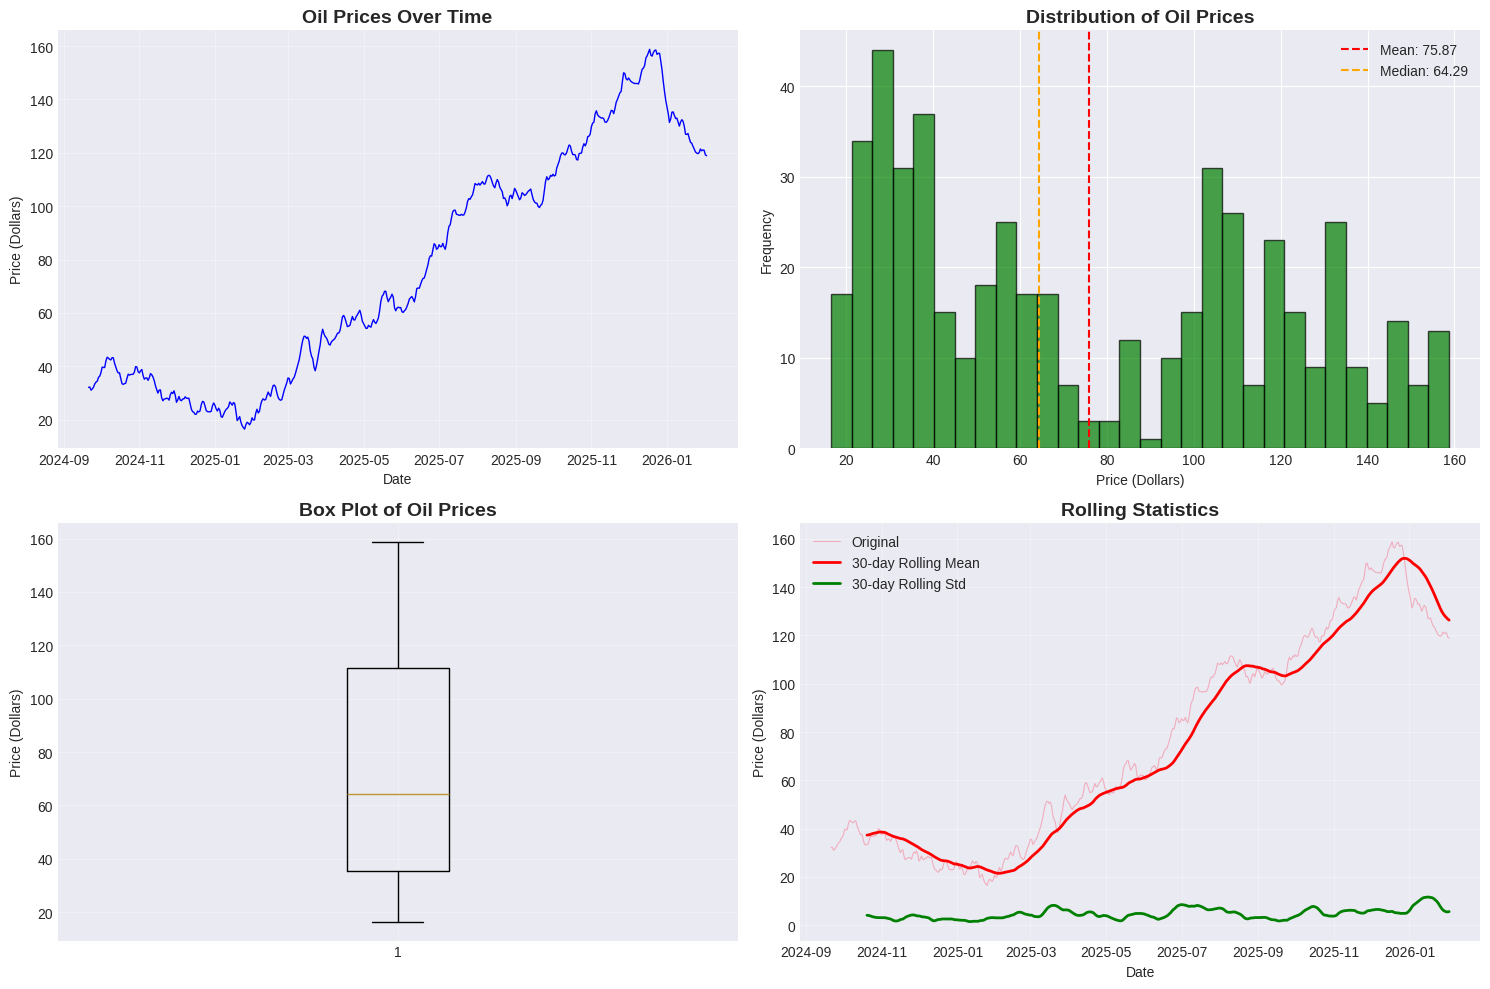


SUMMARY STATISTICS
count    500.000000
mean      75.873980
std       42.912398
min       16.480000
25%       35.372500
50%       64.290000
75%      111.572500
max      158.780000
Name: price, dtype: float64


In [ ]:
# Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Time series plot
axes[0, 0].plot(df.index, df['price'], linewidth=1, color='blue')
axes[0, 0].set_title('Oil Prices Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (Dollars)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Histogram
axes[0, 1].hist(df['price'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Distribution of Oil Prices', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Price (Dollars)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['price'].mean(), color='red', linestyle='--', label=f'Mean: {df["price"].mean():.2f}')
axes[0, 1].axvline(df['price'].median(), color='orange', linestyle='--', label=f'Median: {df["price"].median():.2f}')
axes[0, 1].legend()

# Plot 3: Box plot
axes[1, 0].boxplot(df['price'], vert=True)
axes[1, 0].set_title('Box Plot of Oil Prices', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Price (Dollars)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Rolling statistics
rolling_mean = df['price'].rolling(window=30).mean()
rolling_std = df['price'].rolling(window=30).std()
axes[1, 1].plot(df.index, df['price'], label='Original', alpha=0.5, linewidth=0.8)
axes[1, 1].plot(df.index, rolling_mean, label='30-day Rolling Mean', color='red', linewidth=2)
axes[1, 1].plot(df.index, rolling_std, label='30-day Rolling Std', color='green', linewidth=2)
axes[1, 1].set_title('Rolling Statistics', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Price (Dollars)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(df['price'].describe())



STATIONARITY TEST - ORIGINAL DATA
Results of Dickey-Fuller Test for Original Oil Prices:
ADF Statistic: -0.546234
p-value: 0.882674
Critical Values:
	1%: -3.444
	5%: -2.868
	10%: -2.570
=> Data is NON-STATIONARY (fail to reject H0)


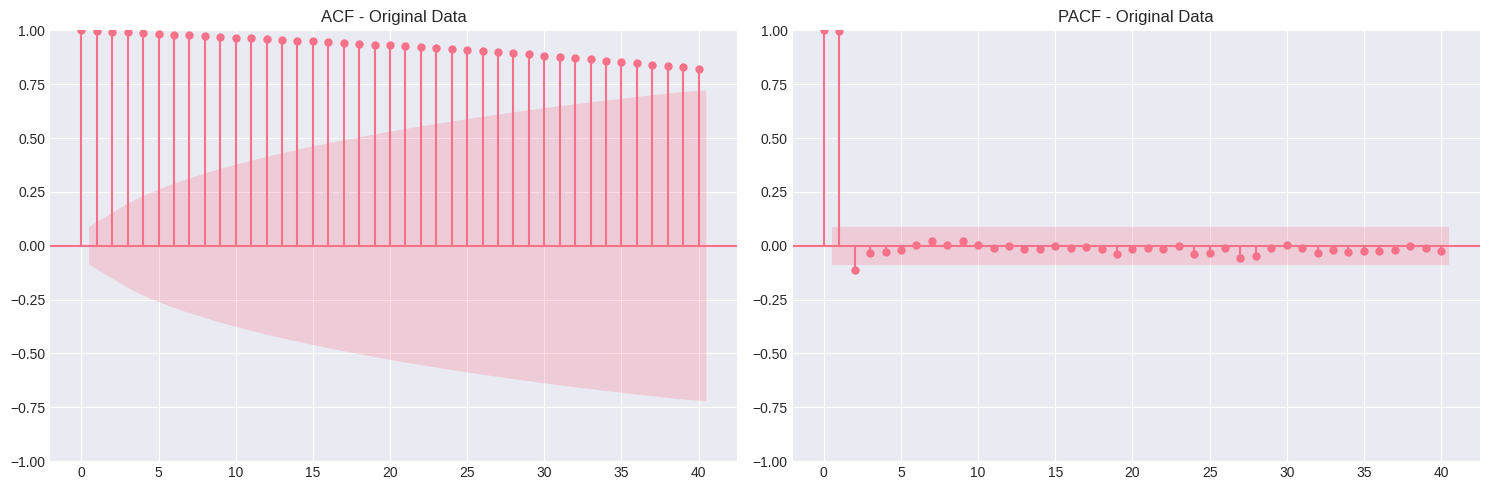

In [ ]:
# Stationarity Tests
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def check_stationarity(timeseries, title):
    """
    Perform Augmented Dickey-Fuller test for stationarity
    """
    # Perform ADF test
    result = adfuller(timeseries.dropna(), autolag='AIC')

    print(f'Results of Dickey-Fuller Test for {title}:')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')

    if result[1] <= 0.05:
        print("=> Data is STATIONARY (reject H0)")
    else:
        print("=> Data is NON-STATIONARY (fail to reject H0)")

    return result[1]

# Check stationarity of original data
print("\n" + "="*50)
print("STATIONARITY TEST - ORIGINAL DATA")
print("="*50)
p_value_original = check_stationarity(df['price'], "Original Oil Prices")

# Plot ACF and PACF for original data
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df['price'], lags=40, ax=axes[0])
axes[0].set_title('ACF - Original Data')
plot_pacf(df['price'], lags=40, ax=axes[1])
axes[1].set_title('PACF - Original Data')
plt.tight_layout()
plt.show()



STATIONARITY TEST - FIRST DIFFERENCE
Results of Dickey-Fuller Test for First Difference:
ADF Statistic: -4.541460
p-value: 0.000165
Critical Values:
	1%: -3.444
	5%: -2.868
	10%: -2.570
=> Data is STATIONARY (reject H0)


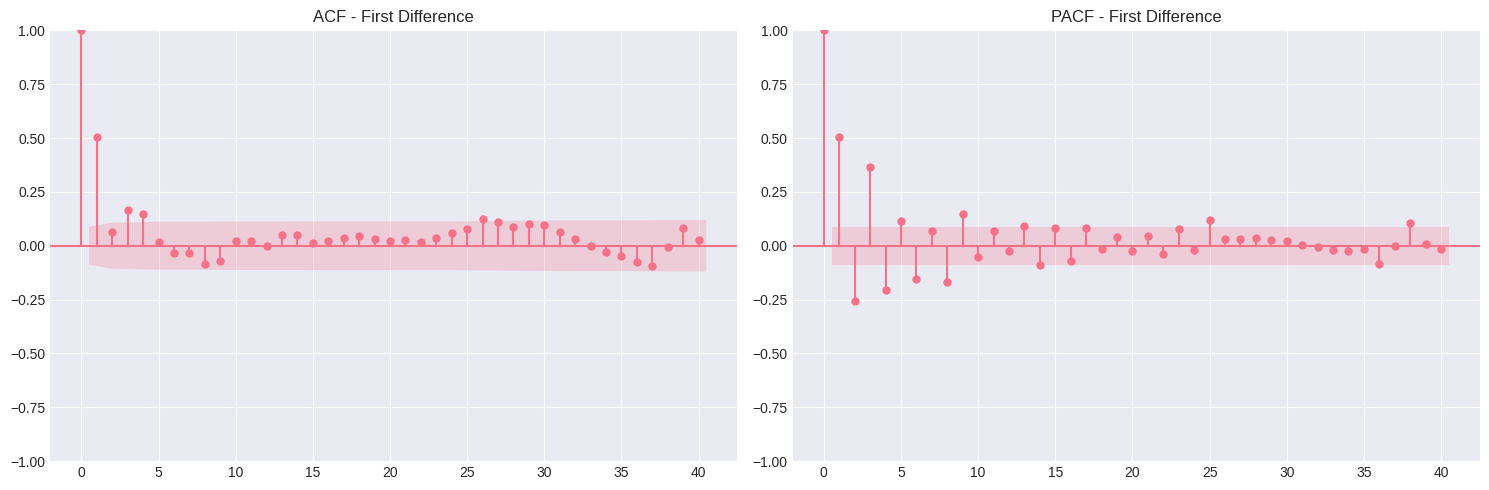

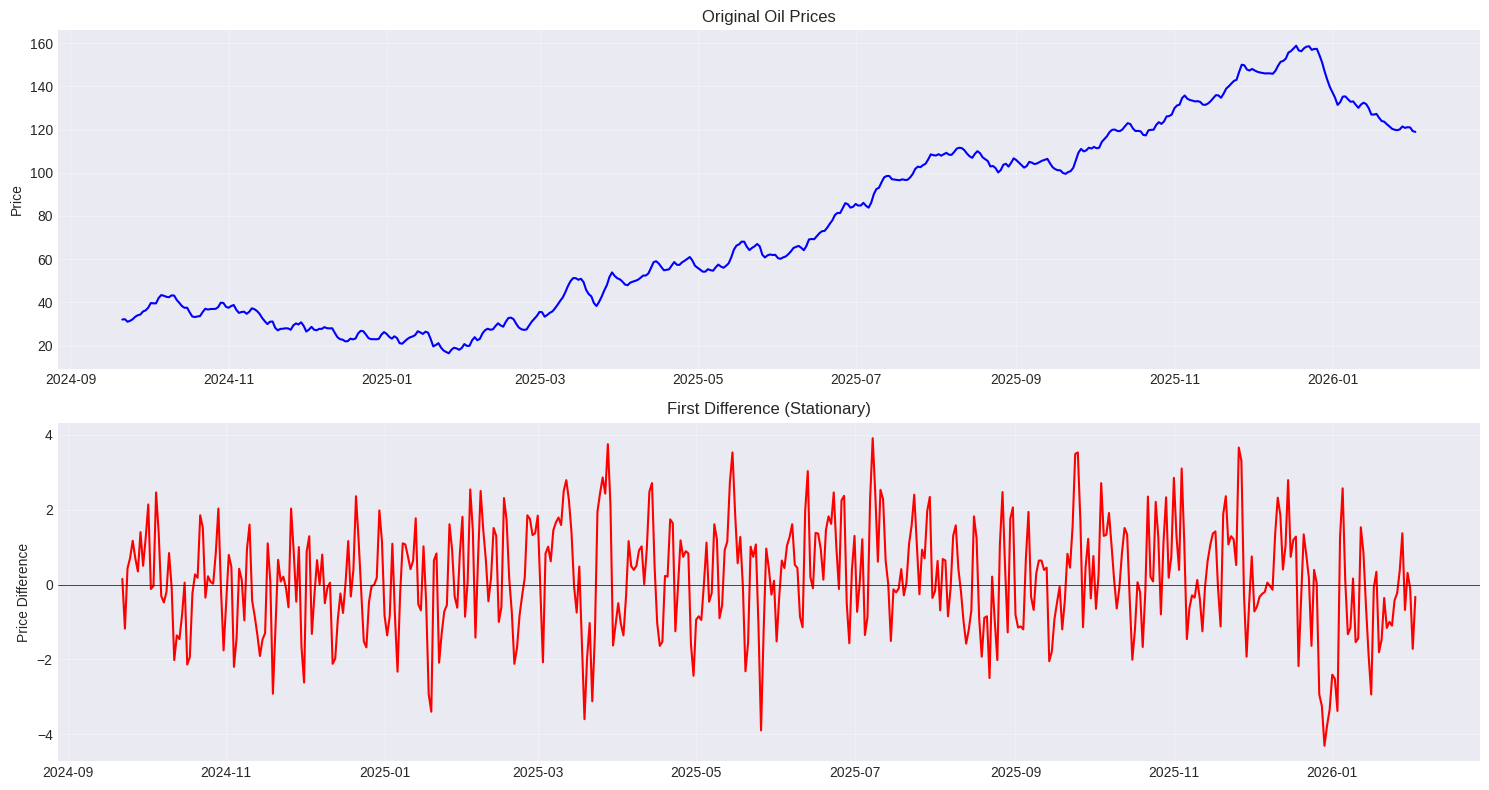

In [ ]:
# Make Data Stationary (if needed)
from statsmodels.tsa.stattools import adfuller
df['price_diff'] = df['price'].diff()
df_diff = df.dropna()

print("\n" + "="*50)
print("STATIONARITY TEST - FIRST DIFFERENCE")
print("="*50)
p_value_diff = check_stationarity(df_diff['price_diff'], "First Difference")

# Plot ACF and PACF for differenced data
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df_diff['price_diff'], lags=40, ax=axes[0])
axes[0].set_title('ACF - First Difference')
plot_pacf(df_diff['price_diff'], lags=40, ax=axes[1])
axes[1].set_title('PACF - First Difference')
plt.tight_layout()
plt.show()

# Plot original vs differenced
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(df.index, df['price'], color='blue')
axes[0].set_title('Original Oil Prices', fontsize=12)
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_diff.index, df_diff['price_diff'], color='red')
axes[1].set_title('First Difference (Stationary)', fontsize=12)
axes[1].set_ylabel('Price Difference')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Split Data for Training and Testing

# Use last 60 days for testing
test_size = 60
train_data = df['price'][:-test_size]
test_data = df['price'][-test_size:]

print(f"Training data: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Training size: {len(train_data)} days")
print(f"Testing data: {test_data.index[0]} to {test_data.index[-1]}")
print(f"Testing size: {len(test_data)} days")



Training data: 2024-09-21 00:00:00 to 2025-12-04 00:00:00
Training size: 440 days
Testing data: 2025-12-05 00:00:00 to 2026-02-02 00:00:00
Testing size: 60 days


In [ ]:
# ARIMA Model - Find Best Parameters
from statsmodels.tsa.arima.model import ARIMA
import itertools
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def find_best_arima(train_data, p_range, d_range, q_range):
    """
    Find best ARIMA parameters using AIC
    """
    best_aic = float('inf')
    best_order = None
    best_model = None

    # Create all possible combinations
    pdq_combinations = list(itertools.product(p_range, d_range, q_range))

    results = []

    for order in tqdm(pdq_combinations, desc="Finding best ARIMA parameters"):
        try:
            model = ARIMA(train_data, order=order)
            model_fit = model.fit()
            aic = model_fit.aic

            results.append({
                'order': order,
                'aic': aic,
                'model': model_fit
            })

            if aic < best_aic:
                best_aic = aic
                best_order = order
                best_model = model_fit

        except:
            continue

    return best_order, best_aic, best_model, results


p_range = range(0, 9)  # p = 0 to 8
d_range = [0, 1, 2]    # d = 0, 1, 2
q_range = range(0, 9)  # q = 0 to 8

print("Searching for best ARIMA parameters...")
best_order, best_aic, best_model, all_results = find_best_arima(train_data, p_range, d_range, q_range)

print(f"\nBest ARIMA order: {best_order}")
print(f"Best AIC: {best_aic:.2f}")

results_df = pd.DataFrame([
    {'order': r['order'], 'aic': r['aic']} for r in all_results
]).sort_values('aic')

print("\nTop 5 models by AIC:")
print(results_df.head())


Searching for best ARIMA parameters...


Finding best ARIMA parameters: 100%|██████████| 243/243 [05:32<00:00,  1.37s/it]


Best ARIMA order: (4, 2, 6)
Best AIC: 1239.91

Top 5 models by AIC:
         order          aic
132  (4, 2, 6)  1239.907513
133  (4, 2, 7)  1240.533546
159  (5, 2, 6)  1241.417173
156  (5, 2, 3)  1241.763734
236  (8, 2, 2)  1242.003702


                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  440
Model:                 ARIMA(4, 2, 6)   Log Likelihood                -608.954
Date:                Sat, 07 Mar 2026   AIC                           1239.908
Time:                        16:41:40   BIC                           1284.812
Sample:                    09-21-2024   HQIC                          1257.626
                         - 12-04-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6030      0.065      9.291      0.000       0.476       0.730
ar.L2         -1.0271      0.070    -14.640      0.000      -1.165      -0.890
ar.L3          0.6022      0.066      9.154      0.0

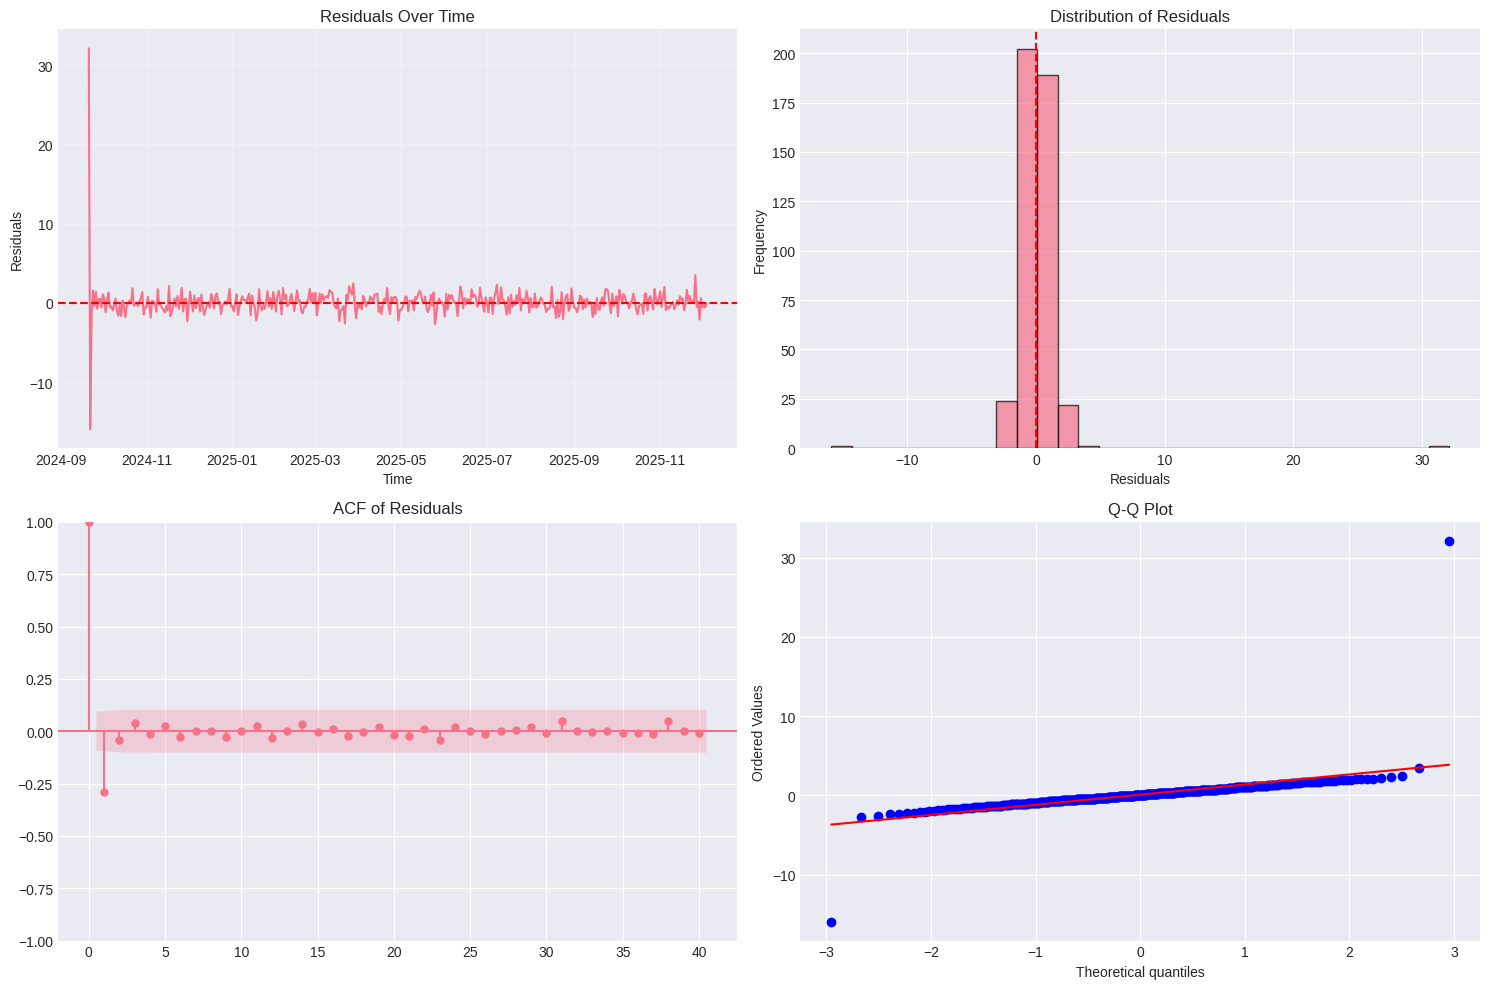


RESIDUAL ANALYSIS
Mean of residuals: 0.098439
Std of residuals: 1.963422
Skewness: 8.655965
Kurtosis: 170.304428

Ljung-Box Test Results:
      lb_stat  lb_pvalue
10  39.686146   0.000019
20  41.731635   0.002997
30  43.453792   0.053407


In [ ]:
# Fit Final ARIMA Model and Check Residuals

# Fit the best model
final_arima = ARIMA(train_data, order=best_order)
final_arima_fit = final_arima.fit()

print(final_arima_fit.summary())
residuals = final_arima_fit.resid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Residuals over time
axes[0, 0].plot(residuals)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals Over Time', fontsize=12)
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, alpha=0.3)

# Histogram of residuals
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Residuals', fontsize=12)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(x=0, color='red', linestyle='--')

# ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF of Residuals', fontsize=12)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot', fontsize=12)

plt.tight_layout()
plt.show()

# Residual statistics
print("\n" + "="*50)
print("RESIDUAL ANALYSIS")
print("="*50)
print(f"Mean of residuals: {residuals.mean():.6f}")
print(f"Std of residuals: {residuals.std():.6f}")
print(f"Skewness: {residuals.skew():.6f}")
print(f"Kurtosis: {residuals.kurtosis():.6f}")

# Ljung-Box test for autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print("\nLjung-Box Test Results:")
print(lb_test)


ARIMA MODEL PERFORMANCE
RMSE: 24.0634
MAE: 19.1710
MAPE: 14.99%


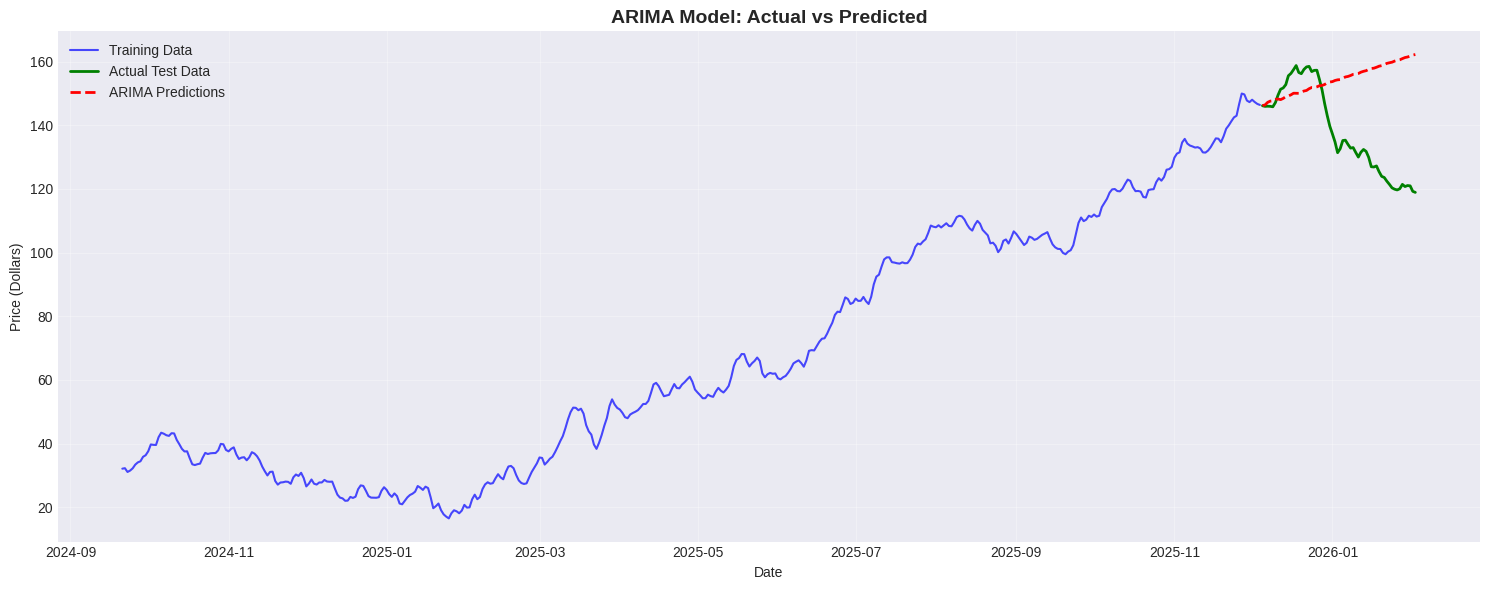

In [ ]:
# ARIMA Forecast and Evaluation

# Make predictions on test set
forecast_steps = len(test_data)
arima_forecast = final_arima_fit.forecast(steps=forecast_steps)
arima_forecast_index = test_data.index

# Calculate RMSE
from sklearn.metrics import mean_squared_error, mean_absolute_error
arima_rmse = np.sqrt(mean_squared_error(test_data, arima_forecast))
arima_mae = mean_absolute_error(test_data, arima_forecast)
arima_mape = np.mean(np.abs((test_data.values - arima_forecast) / test_data.values)) * 100

print("\n" + "="*50)
print("ARIMA MODEL PERFORMANCE")
print("="*50)
print(f"RMSE: {arima_rmse:.4f}")
print(f"MAE: {arima_mae:.4f}")
print(f"MAPE: {arima_mape:.2f}%")

# Plot actual vs predicted
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(train_data.index, train_data, label='Training Data', color='blue', alpha=0.7)
ax.plot(test_data.index, test_data, label='Actual Test Data', color='green', linewidth=2)
ax.plot(test_data.index, arima_forecast, label='ARIMA Predictions', color='red', linestyle='--', linewidth=2)
ax.set_title('ARIMA Model: Actual vs Predicted', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (Dollars)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


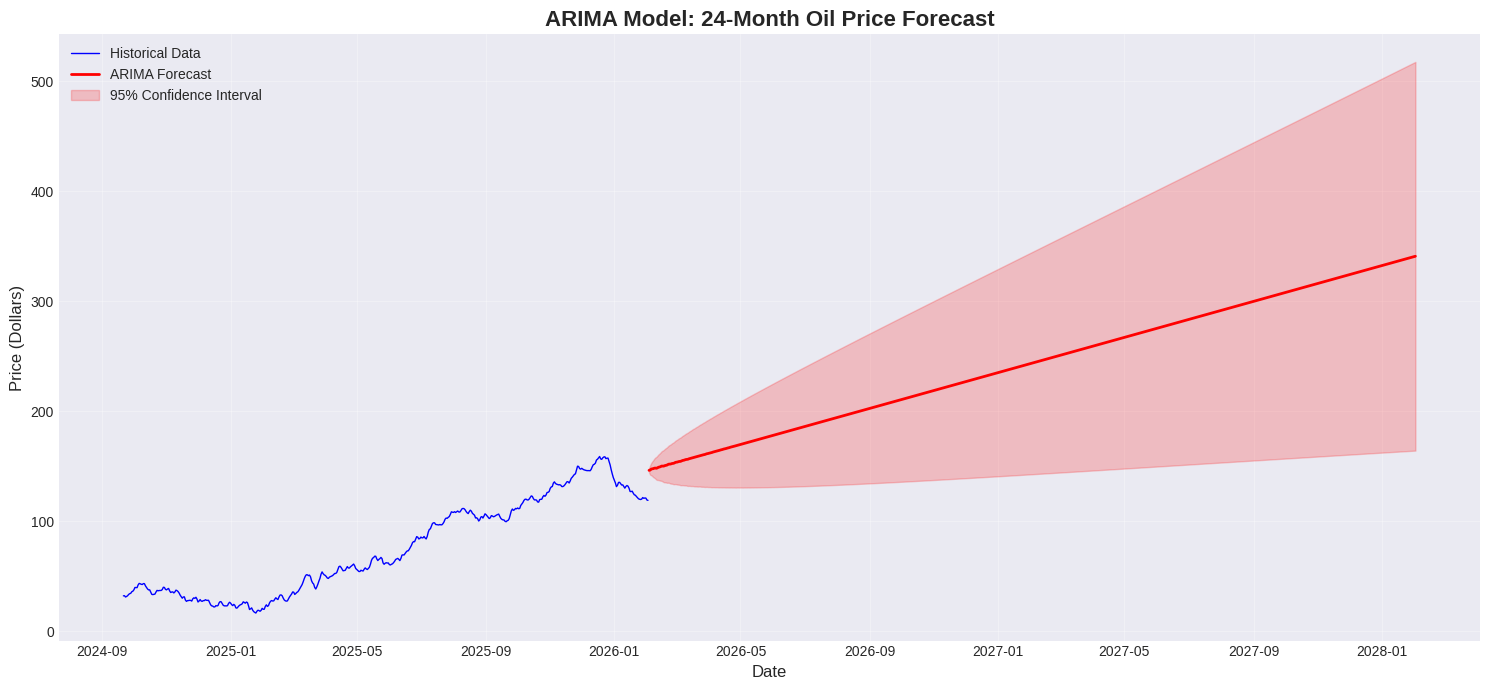


Forecast for 730 days (approximately 24 months)
Forecast range: 2026-02-03 00:00:00 to 2028-02-02 00:00:00


In [ ]:
# ARIMA 24-Month Forecast with Confidence Intervals

# Forecast 24 months (approximately 730 days)
forecast_days = 730
arima_forecast_full = final_arima_fit.forecast(steps=forecast_days)
arima_forecast_full_index = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=forecast_days, freq='D')

# Get confidence intervals
forecast_result = final_arima_fit.get_forecast(steps=forecast_days)
confidence_intervals = forecast_result.conf_int(alpha=0.05)
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(df.index, df['price'], label='Historical Data', color='blue', linewidth=1)
ax.plot(arima_forecast_full_index, arima_forecast_full, label='ARIMA Forecast', color='red', linewidth=2)

# Confidence intervals
ax.fill_between(arima_forecast_full_index,
                confidence_intervals.iloc[:, 0],
                confidence_intervals.iloc[:, 1],
                color='red', alpha=0.2, label='95% Confidence Interval')

ax.set_title('ARIMA Model: 24-Month Oil Price Forecast', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (Dollars)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nForecast for {forecast_days} days (approximately 24 months)")
print(f"Forecast range: {arima_forecast_full_index[0]} to {arima_forecast_full_index[-1]}")

In [ ]:
# Alternative Model - LSTM (Deep Learning)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler


def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['price'].values.reshape(-1, 1))

sequence_length = 60
X, y = create_sequences(scaled_data.flatten(), sequence_length)

# Split into train and test
train_size = len(X) - test_size
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Reshape for LSTM (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


Training samples: 380
Testing samples: 60


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.1337 - mae: 0.2796 - val_loss: 0.0015 - val_mae: 0.0302
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0137 - mae: 0.0984 - val_loss: 0.0273 - val_mae: 0.1627
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0065 - mae: 0.0672 - val_loss: 0.0100 - val_mae: 0.0969
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0037 - mae: 0.0464 - val_loss: 0.0029 - val_mae: 0.0479
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0034 - mae: 0.0442 - val_loss: 0.0035 - val_mae: 0.0537
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0031 - mae: 0.0430 - val_loss: 0.0019 - val_mae: 0.0358
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0032 - mae: 0.0443 - val_loss: 0.0021 - val_mae: 0.0390
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0032 - mae: 0.0431 - val_loss: 0.0092 - val_mae: 0.0926
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.002

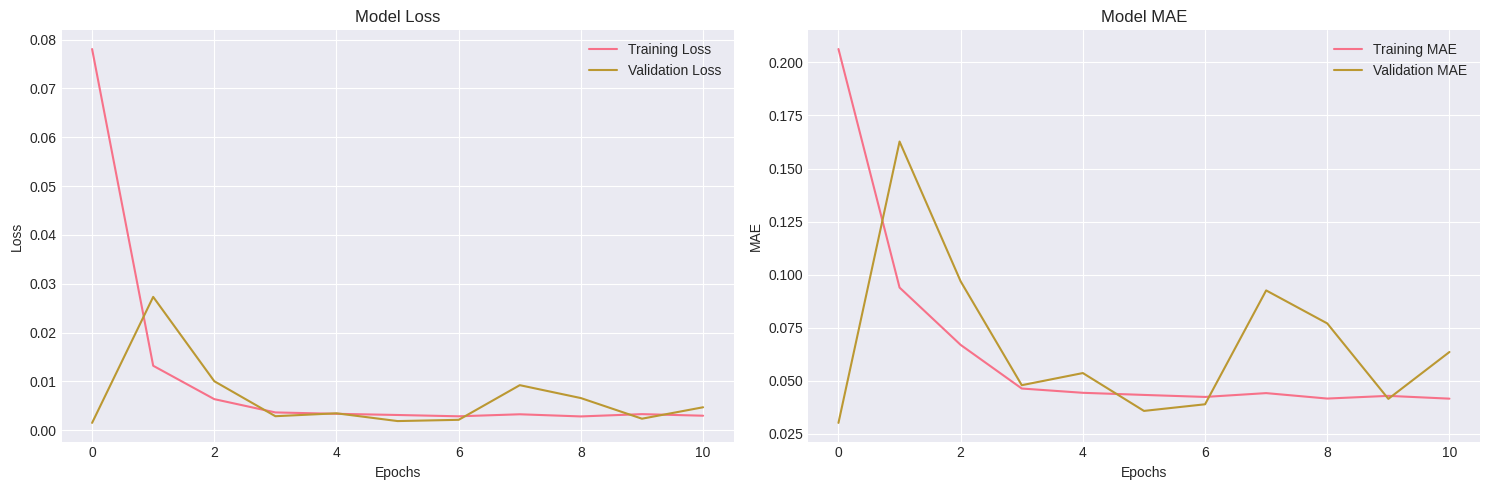

In [ ]:
# Build and Train LSTM Model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0889 - mae: 0.2223 - val_loss: 0.0323 - val_mae: 0.1775
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0107 - mae: 0.0832 - val_loss: 0.0014 - val_mae: 0.0298
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0068 - mae: 0.0690 - val_loss: 0.0122 - val_mae: 0.1078
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0040 - mae: 0.0493 - val_loss: 0.0026 - val_mae: 0.0451
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0038 - mae: 0.0468 - val_loss: 6.8612e-04 - val_mae: 0.0215
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0034 - mae: 0.0434 - val_loss: 0.0019 - val_mae: 0.0362
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0031 - mae: 0.0433 - val_loss: 0.0027 - val_mae: 0.0464
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0028 - mae: 0.0418 - val_loss: 0.0069 - val_mae: 0.0793
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0

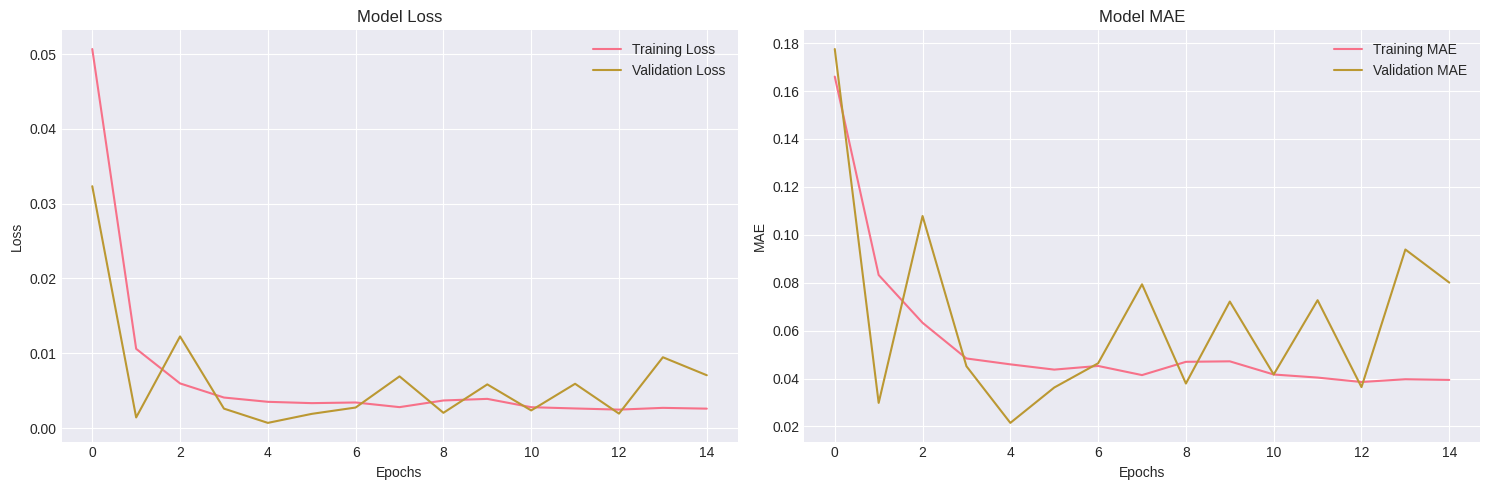

In [ ]:
# Build and Train LSTM Model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

LSTM MODEL PERFORMANCE
RMSE: 15.8600
MAE: 13.1798
MAPE: 10.14%


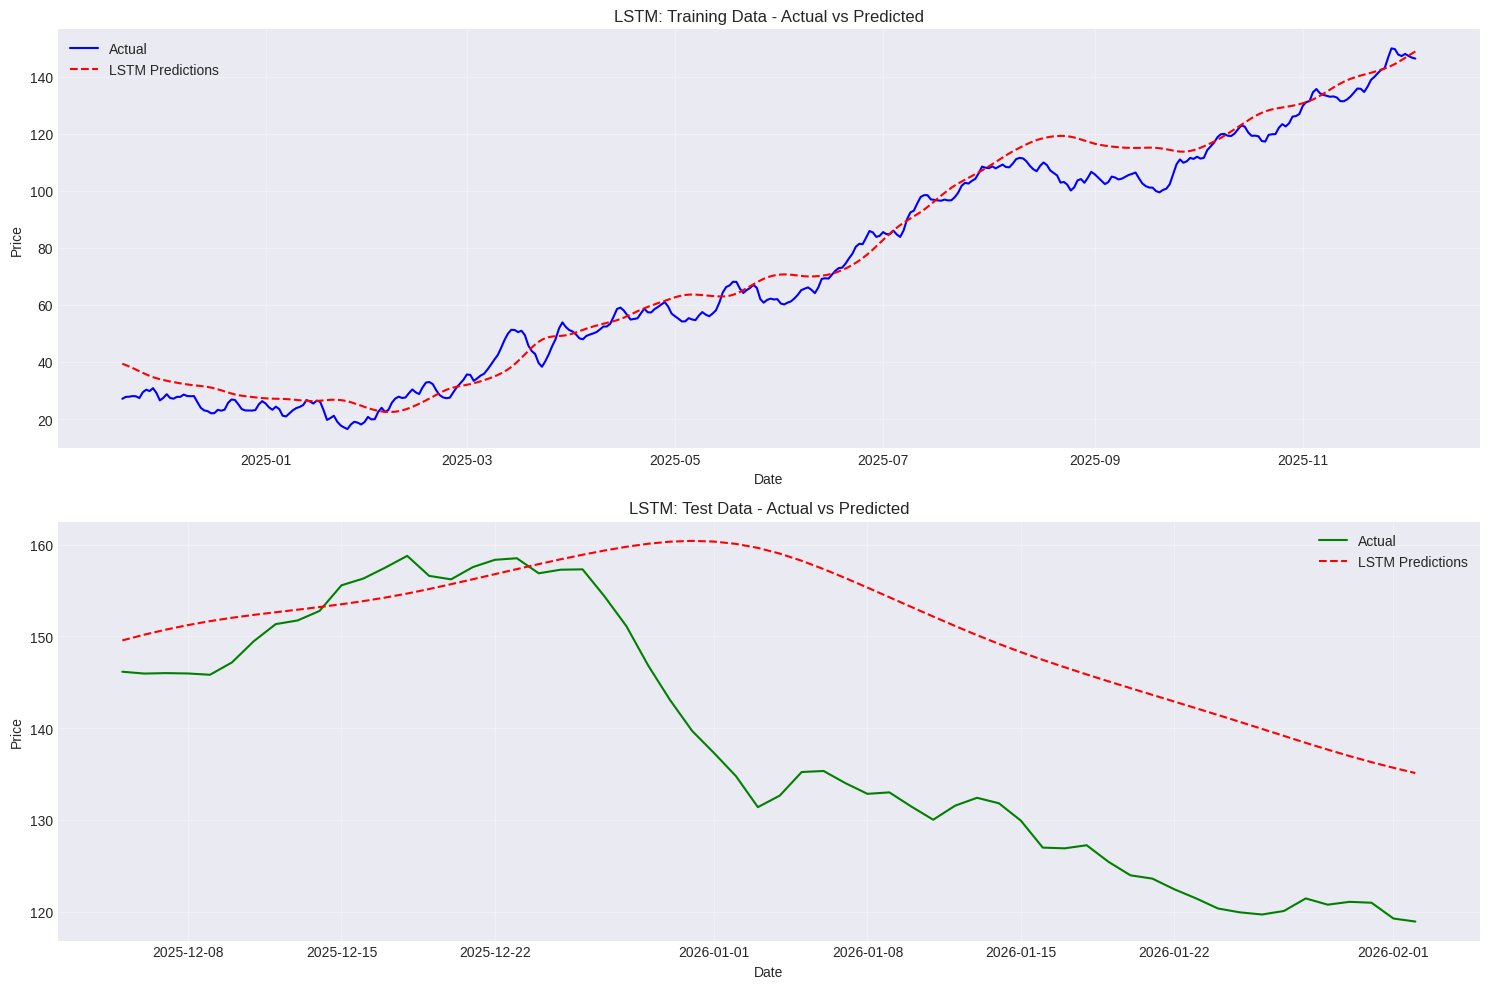

In [ ]:
# LSTM Predictions and Evaluation

# Make predictions
lstm_train_pred = lstm_model.predict(X_train)
lstm_test_pred = lstm_model.predict(X_test)

# Inverse transform predictions
lstm_train_pred = scaler.inverse_transform(lstm_train_pred)
lstm_test_pred = scaler.inverse_transform(lstm_test_pred)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_test_pred))
lstm_mae = mean_absolute_error(y_test_actual, lstm_test_pred)
lstm_mape = np.mean(np.abs((y_test_actual.flatten() - lstm_test_pred.flatten()) / y_test_actual.flatten())) * 100

print("\n" + "="*50)
print("LSTM MODEL PERFORMANCE")
print("="*50)
print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAE: {lstm_mae:.4f}")
print(f"MAPE: {lstm_mape:.2f}%")

# Plot LSTM predictions vs actual
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Training predictions
axes[0].plot(df.index[sequence_length:train_size+sequence_length],
             y_train_actual, label='Actual', color='blue')
axes[0].plot(df.index[sequence_length:train_size+sequence_length],
             lstm_train_pred, label='LSTM Predictions', color='red', linestyle='--')
axes[0].set_title('LSTM: Training Data - Actual vs Predicted', fontsize=12)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Testing predictions
axes[1].plot(df.index[train_size+sequence_length:],
             y_test_actual, label='Actual', color='green')
axes[1].plot(df.index[train_size+sequence_length:],
             lstm_test_pred, label='LSTM Predictions', color='red', linestyle='--')
axes[1].set_title('LSTM: Test Data - Actual vs Predicted', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# FAST LSTM 24-Month Forecast with Confidence Intervals

# Function to make multi-step forecasts
def lstm_forecast(model, last_sequence, n_steps, scaler):
    """
    Make multi-step forecast using LSTM
    """
    current_sequence = last_sequence.copy()
    forecasts = []

    for _ in range(n_steps):
        # Reshape for prediction
        current_input = current_sequence.reshape(1, sequence_length, 1)

        # Make prediction
        pred = model.predict(current_input, verbose=0)
        forecasts.append(pred[0, 0])

        # Update sequence
        current_sequence = np.roll(current_sequence, -1)
        current_sequence[-1] = pred

    # Inverse transform
    forecasts = np.array(forecasts).reshape(-1, 1)
    forecasts = scaler.inverse_transform(forecasts)

    return forecasts.flatten()

# Get last sequence from data
last_sequence = scaled_data[-sequence_length:].flatten()

# Make 24-month forecast (this is the main forecast)
print("Generating LSTM forecast...")
lstm_forecast_values = lstm_forecast(lstm_model, last_sequence, forecast_days, scaler)

# Create index for forecast
lstm_forecast_index = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1),
                                    periods=forecast_days, freq='D')

print("Calculating confidence intervals from test errors...")

# Get prediction errors from test set
test_predictions = lstm_model.predict(X_test, verbose=0)
test_predictions = scaler.inverse_transform(test_predictions)
test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate errors
errors = test_actual.flatten() - test_predictions.flatten()
error_std = np.std(errors)

# Create confidence intervals that widen over time
time_horizon = np.arange(1, forecast_days + 1)
confidence_level = 1.96  # 95% confidence interval

# Uncertainty grows with sqrt(time)
lstm_lower = lstm_forecast_values - confidence_level * error_std * np.sqrt(time_horizon / 30)
lstm_upper = lstm_forecast_values + confidence_level * error_std * np.sqrt(time_horizon / 30)

print(f"Confidence intervals calculated using test error standard deviation: {error_std:.4f}")


Generating LSTM forecast...
Calculating confidence intervals from test errors...
Confidence intervals calculated using test error standard deviation: 9.6558


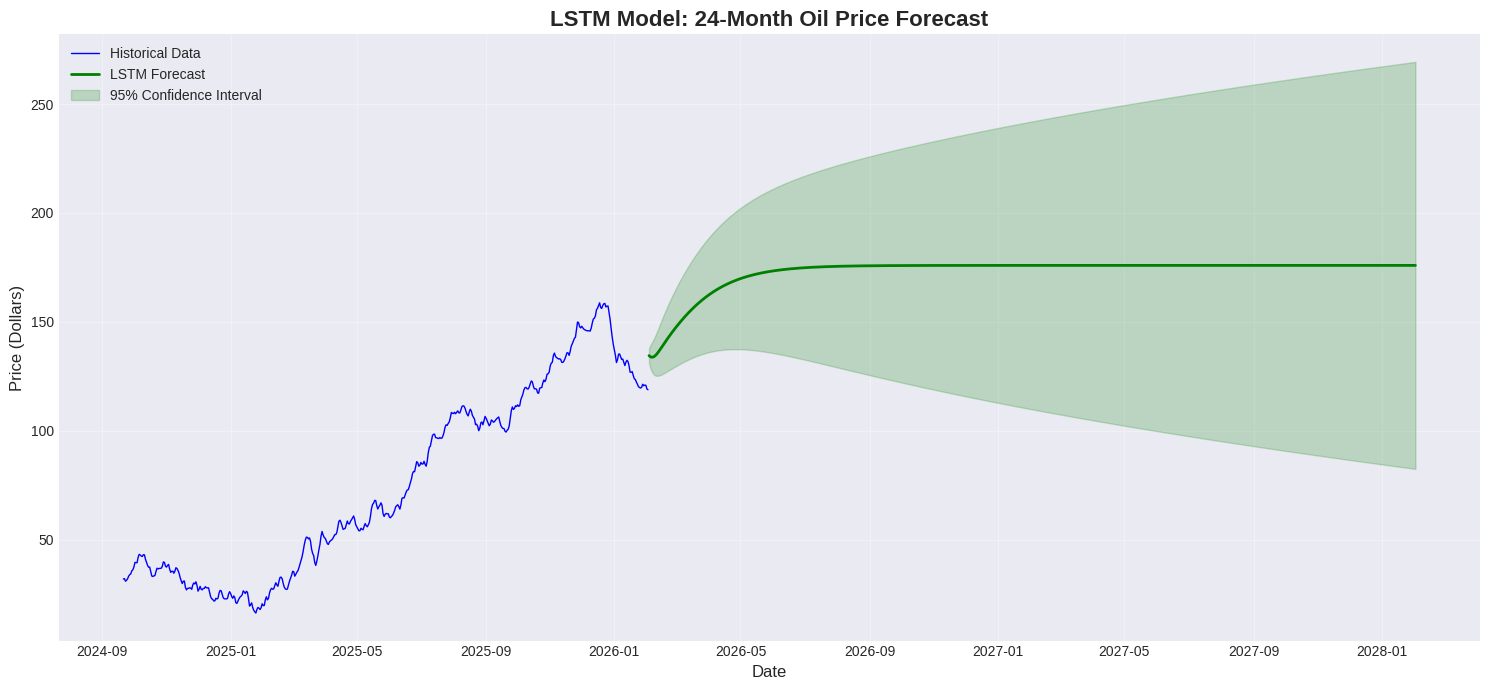

In [ ]:
# Plot LSTM Forecast
fig, ax = plt.subplots(figsize=(15, 7))

# Historical data
ax.plot(df.index, df['price'], label='Historical Data', color='blue', linewidth=1)

# LSTM forecast
ax.plot(lstm_forecast_index, lstm_forecast_values,
        label='LSTM Forecast', color='green', linewidth=2)

# Confidence intervals
ax.fill_between(lstm_forecast_index, lstm_lower, lstm_upper,
                color='green', alpha=0.2, label='95% Confidence Interval')

ax.set_title('LSTM Model: 24-Month Oil Price Forecast', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (Dollars)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




MODEL COMPARISON
Model      RMSE       MAE  MAPE (%)
ARIMA 24.063426 19.171017 14.994320
 LSTM 15.860016 13.179824 10.135931


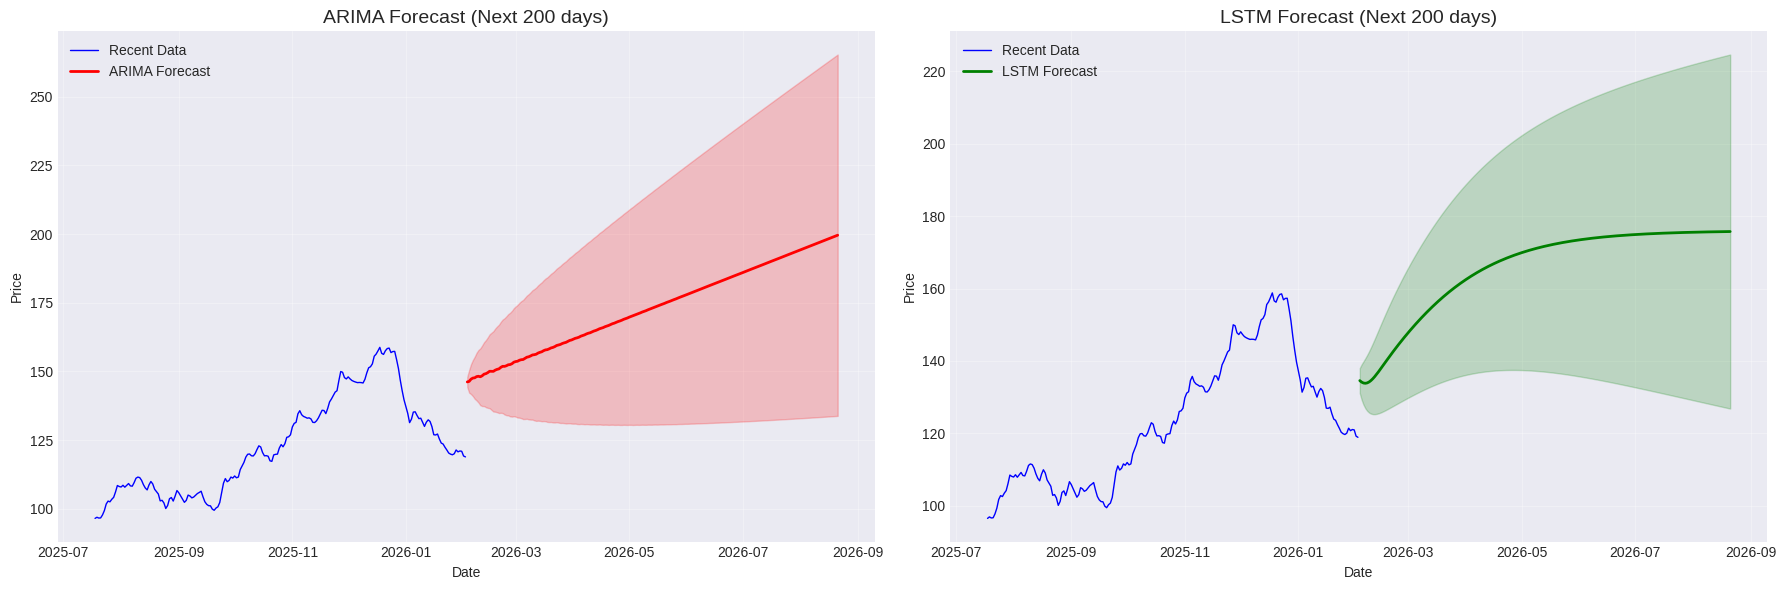

In [ ]:
# Compare Both Models
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
comparison_df = pd.DataFrame({
    'Model': ['ARIMA', 'LSTM'],
    'RMSE': [arima_rmse, lstm_rmse],
    'MAE': [arima_mae, lstm_mae],
    'MAPE (%)': [arima_mape, lstm_mape]
})
print(comparison_df.to_string(index=False))

# Plot comparison of forecasts
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ARIMA forecast
axes[0].plot(df.index[-200:], df['price'][-200:], label='Recent Data', color='blue', linewidth=1)
axes[0].plot(arima_forecast_full_index[:200], arima_forecast_full[:200],
             label='ARIMA Forecast', color='red', linewidth=2)
axes[0].fill_between(arima_forecast_full_index[:200],
                     confidence_intervals.iloc[:200, 0],
                     confidence_intervals.iloc[:200, 1],
                     color='red', alpha=0.2)
axes[0].set_title('ARIMA Forecast (Next 200 days)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LSTM forecast
axes[1].plot(df.index[-200:], df['price'][-200:], label='Recent Data', color='blue', linewidth=1)
axes[1].plot(lstm_forecast_index[:200], lstm_forecast_values[:200],
             label='LSTM Forecast', color='green', linewidth=2)
axes[1].fill_between(lstm_forecast_index[:200], lstm_lower[:200], lstm_upper[:200],
                     color='green', alpha=0.2)
axes[1].set_title('LSTM Forecast (Next 200 days)', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


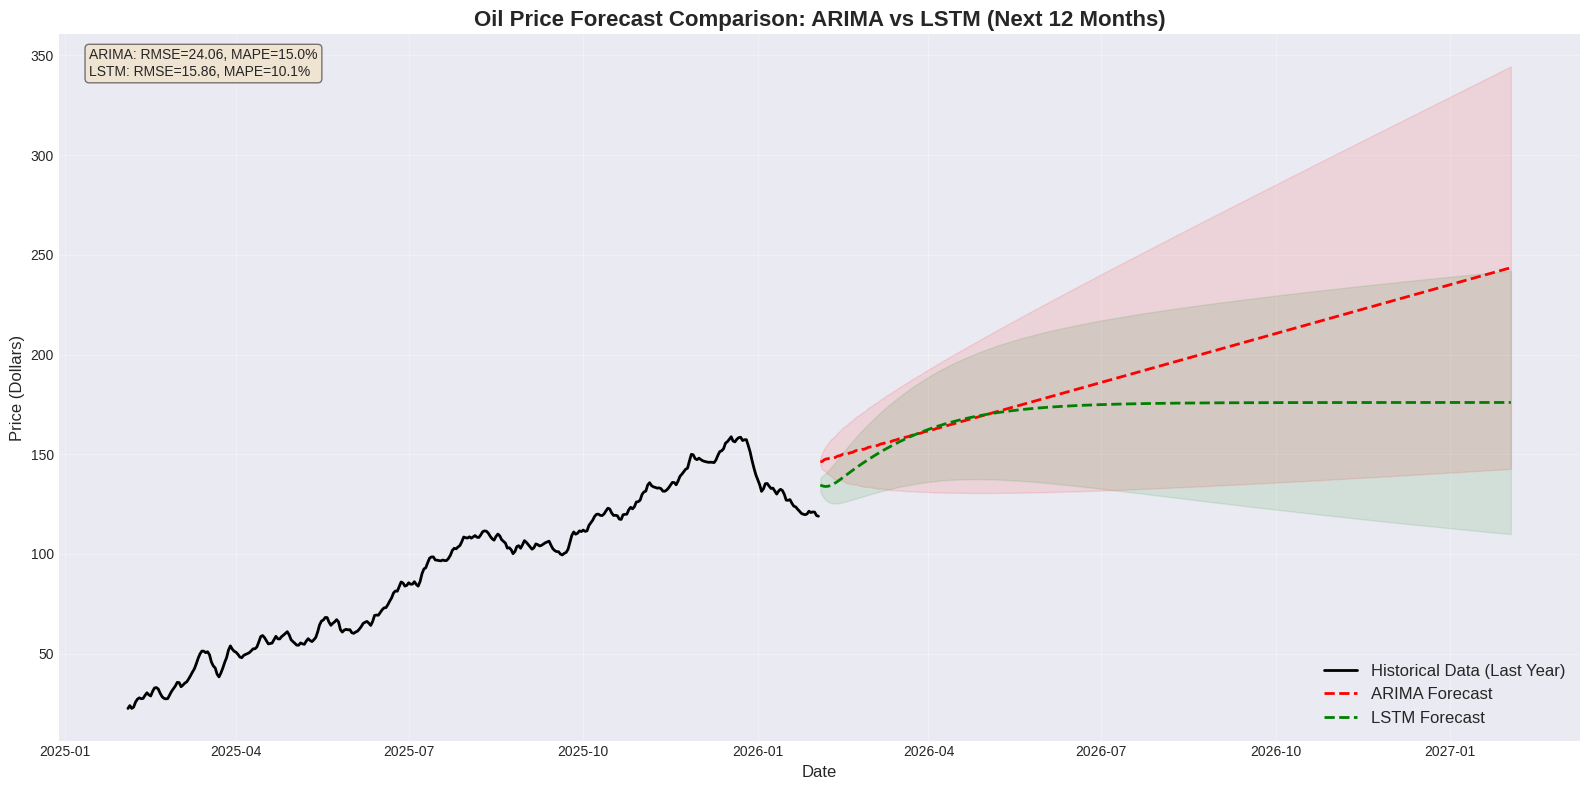

In [ ]:
# Final Comparison Plot
fig, ax = plt.subplots(figsize=(16, 8))

# Historical data
ax.plot(df.index[-365:], df['price'][-365:],
        label='Historical Data (Last Year)', color='black', linewidth=2)

# ARIMA forecast
ax.plot(arima_forecast_full_index[:365], arima_forecast_full[:365],
        label='ARIMA Forecast', color='red', linewidth=2, linestyle='--')
ax.fill_between(arima_forecast_full_index[:365],
                confidence_intervals.iloc[:365, 0],
                confidence_intervals.iloc[:365, 1],
                color='red', alpha=0.1)

# LSTM forecast
ax.plot(lstm_forecast_index[:365], lstm_forecast_values[:365],
        label='LSTM Forecast', color='green', linewidth=2, linestyle='--')
ax.fill_between(lstm_forecast_index[:365], lstm_lower[:365], lstm_upper[:365],
                color='green', alpha=0.1)

ax.set_title('Oil Price Forecast Comparison: ARIMA vs LSTM (Next 12 Months)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (Dollars)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Add text box with metrics
textstr = f'ARIMA: RMSE={arima_rmse:.2f}, MAPE={arima_mape:.1f}%\nLSTM: RMSE={lstm_rmse:.2f}, MAPE={lstm_mape:.1f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()


In [ ]:
# Save Results

# Create results dataframe
forecast_results = pd.DataFrame({
    'date': arima_forecast_full_index,
    'arima_forecast': arima_forecast_full,
    'arima_lower_ci': confidence_intervals.iloc[:, 0].values,
    'arima_upper_ci': confidence_intervals.iloc[:, 1].values,
    'lstm_forecast': lstm_forecast_values,
    'lstm_lower_ci': lstm_lower,
    'lstm_upper_ci': lstm_upper
})

# Save to CSV
forecast_results.to_csv('oil_price_forecasts.csv', index=False)
print("Forecast results saved to 'oil_price_forecasts.csv'")

# Save model performance metrics
metrics_df = pd.DataFrame({
    'Model': ['ARIMA', 'LSTM'],
    'RMSE': [arima_rmse, lstm_rmse],
    'MAE': [arima_mae, lstm_mae],
    'MAPE': [arima_mape, lstm_mape],
    'Best_Parameters': [f"({best_order[0]},{best_order[1]},{best_order[2]})", "LSTM(50,50,50)"]
})
metrics_df.to_csv('model_performance.csv', index=False)
print("Model performance saved to 'model_performance.csv'")

Forecast results saved to 'oil_price_forecasts.csv'
Model performance saved to 'model_performance.csv'


In [ ]:
# Summary Statistics
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Data Analysis Period: {df.index[0]} to {df.index[-1]}")
print(f"Total Days: {len(df)}")
print(f"Average Price: ${df['price'].mean():.2f}")
print(f"Min Price: ${df['price'].min():.2f}")
print(f"Max Price: ${df['price'].max():.2f}")
print(f"Price Volatility (Std): ${df['price'].std():.2f}")
print("\n" + "="*60)
print("FORECAST SUMMARY (24 Months)")
print("="*60)
print(f"ARIMA Forecast - Final Price: ${arima_forecast_full[-1]:.2f}")
print(f"ARIMA Forecast - Average: ${arima_forecast_full.mean():.2f}")
print(f"LSTM Forecast - Final Price: ${lstm_forecast_values[-1]:.2f}")
print(f"LSTM Forecast - Average: ${lstm_forecast_values.mean():.2f}")


FINAL SUMMARY
Data Analysis Period: 2024-09-21 00:00:00 to 2026-02-02 00:00:00
Total Days: 500
Average Price: $75.87
Min Price: $16.48
Max Price: $158.78
Price Volatility (Std): $42.91

FORECAST SUMMARY (24 Months)
ARIMA Forecast - Final Price: $340.85
ARIMA Forecast - Average: $243.70
LSTM Forecast - Final Price: $175.97
LSTM Forecast - Average: $173.11
